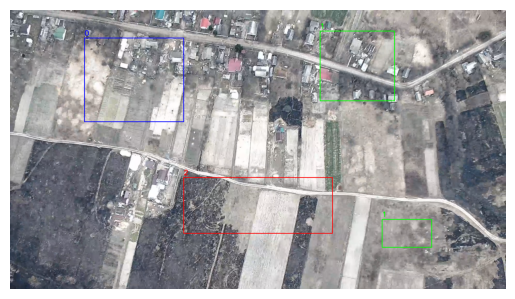

In [1]:
# Лабораторна робота: Розмітка супутникового знімка

# Завдання:
# 1. Створіть новий тип даних (клас) для інструменту розмітки (наприклад, RectangleTool).
# 2. Використайте існуючі типи даних (списки, словники, кортежі) для зберігання координат та параметрів.
# 3. Реалізуйте базові конструкції Python: if, for, while для взаємодії з користувачем та обробки даних.
# 4. Створіть функцію для завантаження координат і класу розмічених об'єктів з файлу sample_yolo.txt.
# 5. Відобразіть розмічені об'єкти на зображенні і підберіть відповідний колір до класу.

import cv2
import matplotlib.pyplot as plt

# Кольори для класів (наприклад, 0 - червоний, 1 - зелений, 2 - синій)
CLASS_COLORS = {
    '0': (255, 0, 0),    # Red
    '1': (0, 255, 0),    # Green
    '2': (0, 0, 255),    # Blue
}

class RectangleTool:
    def __init__(self):
        self.rectangles = []  # список для зберігання координат прямокутників
        self.rois = {}

    def add_rectangle(self, x1, y1, x2, y2, label=None):
        rect = {'coords': (x1, y1, x2, y2), 'label': label}
        self.rectangles.append(rect)

    def draw(self, image):
        img_copy = image.copy()
        for rect in self.rectangles:
            x1, y1, x2, y2 = rect['coords']
            label = rect['label']
            color = CLASS_COLORS.get(label, (255, 255, 255))  # default white
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
            if label is not None:
                cv2.putText(img_copy, label, (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
        return img_copy
    
    def crop_and_save(self, image):
        """Обрізає об'єкти по боксах та зберігає в окрему папку."""
        os.makedirs(output_dir, exist_ok=True)
        
        for i, rect in enumerate(self.rectangles):
            x1, y1, x2, y2 = rect['coords']
            label = rect['label']
            
            crop = image[y1:y2, x1:x2]


def load_yolo_rectangles(filename, img_w, img_h):
    rectangles = []
    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                label, x_center, y_center, w, h = parts
                x_center = float(x_center) * img_w
                y_center = float(y_center) * img_h
                w = float(w) * img_w
                h = float(h) * img_h
                x1 = int(x_center - w/2)
                y1 = int(y_center - h/2)
                x2 = int(x_center + w/2)
                y2 = int(y_center + h/2)
                rectangles.append({'coords': (x1, y1, x2, y2), 'label': label})
    return rectangles


# Завантажуємо зображення
image = cv2.imread("input.png")
img_h, img_w = image.shape[:2]

# Завантаження координат з файлу
yolo_rects = load_yolo_rectangles('sample_yolo.txt', img_w, img_h)

# Створюємо інструмент розмітки
rectangle_tool = RectangleTool()

# Додаємо прямокутники до інструменту
for rect in yolo_rects:
    rectangle_tool.add_rectangle(*rect['coords'], label=rect['label'])

# Відображення розмічених об'єктів з кольорами по класу
result_img = rectangle_tool.draw(image)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


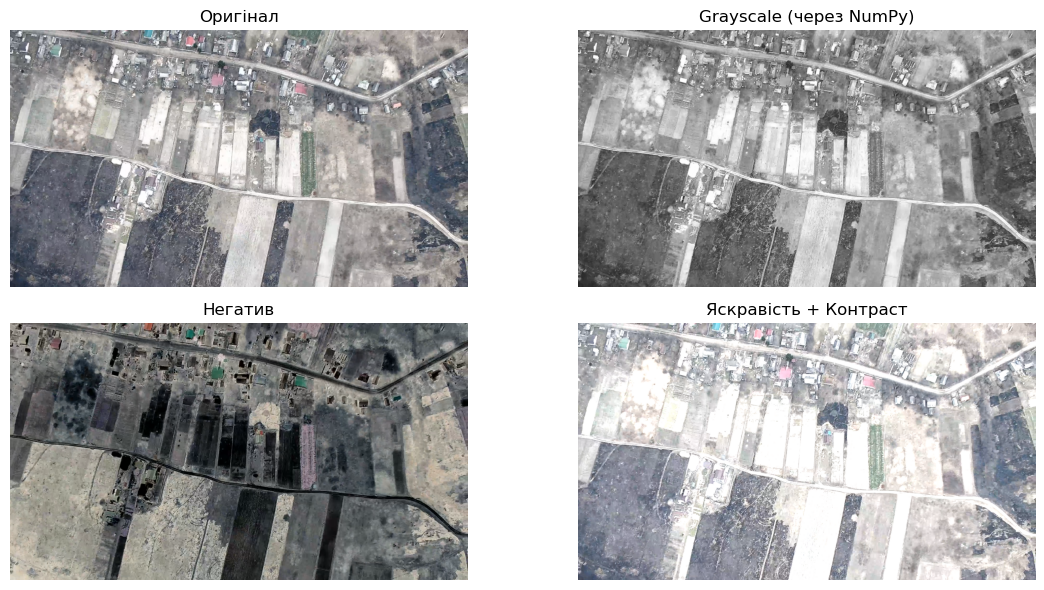

In [2]:
# Лабораторна робота №3
# Тема: NumPy для Computer Vision
# Завдання: grayscale, негатив, яскравість, контраст

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Зчитуємо зображення (BGR)
image = cv2.imread('input.png').astype(np.float32) / 255.0  # нормалізація до [0,1]

# --- 1. Ручне перетворення у grayscale ---
# Формула: Gray = 0.299*R + 0.587*G + 0.114*B
gray = 0.299 * image[:, :, 2] + 0.587 * image[:, :, 1] + 0.114 * image[:, :, 0]

# --- 2. Негатив ---
# Інвертуємо яскравість
negative = 1.0 - image

# --- 3. Яскравість і контраст ---
# brightness - зсув яскравості, contrast - коефіцієнт підсилення
brightness = 0.1   # збільшуємо на 10%
contrast = 1.2     # посилюємо контраст
bright_contrast = np.clip(contrast * image + brightness, 0, 1)

# --- Візуалізація результатів ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title("Оригінал")
plt.imshow(cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Grayscale (через NumPy)")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Негатив")
plt.imshow(cv2.cvtColor((negative * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Яскравість + Контраст")
plt.imshow(cv2.cvtColor((bright_contrast * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


In [3]:
import cv2
import numpy as np
import os
import subprocess

# Папка для кадрів
os.makedirs("frames", exist_ok=True)

# Генеруємо 30 кадрів з градієнтом
for i in range(30):
    frame = np.zeros((240, 320, 3), dtype=np.uint8)
    frame[:, :, 0] = np.linspace(0, 255, 320, dtype=np.uint8)
    frame[:, :, 1] = i * 8
    frame[:, :, 2] = 255 - frame[:, :, 0]
    cv2.imwrite(f"frames/frame_{i:03d}.png", frame)

# Створення відео з фреймів за допомогою ffmpeg
subprocess.run([
    "ffmpeg", "-y",
    "-framerate", "10",                 # 10 кадрів/сек
    "-i", "frames/frame_%03d.png",      # шаблон імен файлів
    "-c:v", "libx264", "-pix_fmt", "yuv420p",
    "output.mp4"
])

print("✅ Відео збережено у 'output.mp4'")

# Для програвання відео всередині контейнера (без GUI)
# Використай команду:
# ffplay -nodisp -autoexit output.mp4


✅ Відео збережено у 'output.mp4'


ffmpeg version 7.1.2 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -flto=auto -ffat-lto-objects -fexceptions -g -grecord-gcc-switches -pipe -Wall -Wno-complain-wrong-lang -Werror=format-security -Wp,-U_FORTIFY_SOURCE,-D_FORTIFY_SOURCE=3 -Wp,-D_GLIBCXX_ASSERTIONS -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -fstack-protector-strong -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -march=x86-64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection -mtls-dialect=gnu2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer' --extra-ldflags='-Wl,-z,relro -Wl,--as-needed -Wl,-z,pack-relative-relocs -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -Wl,--build-id=sha1 -specs=/

In [4]:
from IPython.display import Video

# Програвання mp4 відео прямо у ноутбуці
Video("output.mp4", embed=True, width=400, height=300)

In [5]:
import json

# Завантажуємо розмітку
with open("COCO/annotations.json", "r") as f:
    annotations = json.load(f)

# Структура COCO:
# annotations['images'] - список кадрів: {'id': int, 'file_name': str, ...}
# annotations['annotations'] - список об'єктів: {'image_id': int, 'bbox':[x,y,width,height], 'category_id': int}

# Створюємо словник: кадр -> список боксов
frame_boxes = {}
for ann in annotations['annotations']:
    image_id = ann['image_id']
    bbox = ann['bbox']  # [x, y, width, height]
    category = ann['category_id']

    # Конвертуємо bbox у формат (x1, y1, x2, y2)
    x1, y1, w, h = bbox
    x2 = int(x1 + w)
    y2 = int(y1 + h)
    x1, y1 = int(x1), int(y1)

    if image_id not in frame_boxes:
        frame_boxes[image_id] = []
    frame_boxes[image_id].append({'coords': (x1, y1, x2, y2), 'label': str(category)})

print(frame_boxes)

{1: [{'coords': (472, 358, 509, 382), 'label': '1'}], 2: [{'coords': (472, 357, 509, 381), 'label': '1'}], 3: [{'coords': (472, 357, 509, 380), 'label': '1'}], 4: [{'coords': (472, 356, 509, 380), 'label': '1'}], 5: [{'coords': (471, 355, 509, 379), 'label': '1'}], 6: [{'coords': (471, 355, 509, 379), 'label': '1'}], 7: [{'coords': (471, 354, 509, 378), 'label': '1'}], 8: [{'coords': (471, 354, 509, 377), 'label': '1'}], 9: [{'coords': (471, 353, 509, 377), 'label': '1'}], 10: [{'coords': (471, 352, 509, 376), 'label': '1'}], 11: [{'coords': (471, 351, 508, 374), 'label': '1'}], 12: [{'coords': (471, 349, 508, 373), 'label': '1'}], 13: [{'coords': (471, 347, 508, 371), 'label': '1'}], 14: [{'coords': (471, 346, 508, 370), 'label': '1'}], 15: [{'coords': (471, 345, 508, 369), 'label': '1'}], 16: [{'coords': (471, 345, 508, 368), 'label': '1'}], 17: [{'coords': (471, 344, 508, 367), 'label': '1'}], 18: [{'coords': (471, 343, 508, 366), 'label': '1'}], 19: [{'coords': (471, 341, 508, 365)

In [15]:
############################
##### ВЛАСНЕ ВИКОНАННЯ #####
# завдання починається тут #
############################

# Можна регулювати самому швидкість перегортання кадрів:
fps = 15

# Висота і ширина будуть обчислені як розмір найбільшого кадру;
# функція дозволяє підігнати кадр під розміри центровано, створюючи чорну рамку.
width, height = 0, 0
def pad_frame(frame, width, height):
    h, w = frame.shape[:2]
    top = (height - h) // 2
    bottom = (height - h) - top
    left = (width - w) // 2
    right = (width - w) - left
    return cv2.copyMakeBorder(frame, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(0, 0, 0))

# Створюємо список кадрів з областей інтересу:
roi_frames = []
for frame in annotations['images']:
    # Для кожного зображення (кадру) img_data з COCO файлу анотацій,
    img_id = frame['id']
    img_data = cv2.imread(f"COCO/images/default/{frame['file_name']}")

    # вибираємо лише ті, де помічені ROI;
    rois = []
    if img_id not in frame_boxes:
        continue
    # вирізаємо ROI та підвищуємо контраст, додаємо до тимчасового списку;
    for roi_desc in frame_boxes[img_id]:
        x1, y1, x2, y2 = roi_desc['coords']
        label = roi_desc['label']
        roi_crop = img_data[y1:y2, x1:x2]
        if label == 1:
            roi_crop = np.clip(roi_crop * 1.5, 0, 255).astype(np.uint8)
        rois.append(roi_crop)

    # комбінуємо вертикально, зберігаємо до списку кадрів та визначаємо, чи це найбільший кадр.
    combined = np.hstack(rois)
    h, w = combined.shape[:2]
    width = max(width, w)
    height = max(height, h)
    roi_frames.append(combined)
# Масштабуємо всі кадри під однаковий розмір описаною вище функцією.
roi_frames = [pad_frame(frame, width, height) for frame in roi_frames]

# Записуємо відео до файлу (кодек avc1 для найкращої сумісності з браузерами і Jupyter).
out = cv2.VideoWriter('output_boxes.mp4', cv2.VideoWriter_fourcc(*'avc1'), fps, (width, height))
for frame in roi_frames:
    out.write(frame)
out.release()

# Відображаємо відео нижче.
Video("output_boxes.mp4", embed = True)